In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers datasets sentencepiece accelerate

Mounted at /content/drive


In [2]:
import os
import zipfile
import json
import random
import shutil
from tqdm import tqdm

# 1. PATHS
zip_path = "/content/drive/MyDrive/PlotQA-Stemsight/line_plots_train.zip"
extract_path = "/content/line_temp"
master_dir = "/content/line_donut_master"

# 2. UNZIP
print("📦 Unzipping Line Train data...")
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 3. SAMPLE 10,000 IMAGES (Adjusted for the /train subfolder)
print("🔍 Syncing metadata and sampling from the /train subfolder...")

# FIX: Added 'train' to the path
jsonl_path = os.path.join(extract_path, "train", "metadata.jsonl")
image_source_dir = os.path.join(extract_path, "train")

if not os.path.exists(jsonl_path):
    print(f"❌ ERROR: Still can't find it! Check this path manually: {jsonl_path}")
else:
    with open(jsonl_path, 'r') as f:
        lines = f.readlines()

    random.shuffle(lines)
    os.makedirs(master_dir, exist_ok=True)

    selected_lines = []
    count = 0
    for line in tqdm(lines):
        if count >= 10000: break
        data = json.loads(line)
        img_name = data['file_name']

        # FIX: Look inside the 'train' folder for the image
        src = os.path.join(image_source_dir, img_name)

        if os.path.exists(src):
            shutil.copy(src, os.path.join(master_dir, img_name))
            selected_lines.append(data)
            count += 1

    # Save the new sampled metadata
    with open(os.path.join(master_dir, "metadata.jsonl"), 'w') as f:
        for entry in selected_lines:
            f.write(json.dumps(entry) + "\n")

    print(f"✅ Success! {len(selected_lines)} samples ready in {master_dir}")

📦 Unzipping Line Train data...
🔍 Syncing metadata and sampling from the /train subfolder...


 39%|███▊      | 10000/25897 [00:03<00:05, 3060.21it/s]

✅ Success! 10000 samples ready in /content/line_donut_master


In [4]:
import os
import json
import torch
from torch.optim import AdamW # The "Expert" Optimizer with Weight Decay
from datasets import load_dataset
from transformers import DonutProcessor, VisionEncoderDecoderModel, TrainingArguments, Trainer

# 1. LOAD DATASET
dataset = load_dataset("imagefolder", data_dir="/content/line_donut_master")

# 2. LOAD YOUR VBAR MODEL AS THE BASE
model_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to("cuda")
model.config.tie_word_embeddings = False

# 3. DATA COLLATOR
def donut_collator(batch):
    pixel_values = [item["image"].convert("RGB") for item in batch]
    pixel_values = processor(pixel_values, return_tensors="pt").pixel_values
    labels = [json.loads(item["ground_truth"])["gt_parse"] for item in batch]
    labels = processor.tokenizer(labels, padding="max_length", truncation=True,
                                 max_length=256, return_tensors="pt").input_ids
    labels[labels == processor.tokenizer.pad_token_id] = -100
    return {"pixel_values": pixel_values, "labels": labels}

# 4. PATHS & TRAINING CONFIG
LINE_SAVE_PATH = "/content/drive/MyDrive/STEM_Sight_Line_V1"
os.makedirs(LINE_SAVE_PATH, exist_ok=True)

training_args = TrainingArguments(
    output_dir=LINE_SAVE_PATH,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,     # Effective batch of 16
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,                 # <--- Your Weight Decay is right here
    logging_steps=100,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    fp16=True,
    remove_unused_columns=False,
    report_to="none"
)

# 5. INITIALIZE TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=donut_collator,
)

print("🚀 Launching Line Chart Expert Training (Weight Decay enabled)...")
trainer.train()

Resolving data files:   0%|          | 0/10001 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


🚀 Launching Line Chart Expert Training (Weight Decay enabled)...


Step,Training Loss
100,0.357559
200,0.201754
300,0.204696
400,0.188886
500,0.162800
600,0.158859
700,0.116951
800,0.100244
900,0.085726
1000,0.073385


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.10884655272165934, metrics={'train_runtime': 3693.0754, 'train_samples_per_second': 8.123, 'train_steps_per_second': 0.508, 'total_flos': 1.594731338661888e+19, 'train_loss': 0.10884655272165934, 'epoch': 3.0})

In [5]:
# 1. Create the final clean folder
final_save_path = "/content/drive/MyDrive/STEM_Sight_Line_Final"
trainer.save_model(final_save_path)
processor.save_pretrained(final_save_path)

print(f"✅ Line Expert is locked and loaded at: {final_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Line Expert is locked and loaded at: /content/drive/MyDrive/STEM_Sight_Line_Final


In [6]:
import torch
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel

# 1. Load the Expert you just created
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "/content/drive/MyDrive/STEM_Sight_Line_Final"

processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to(device)

def test_line_expert(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    # Generate the summary
    task_prompt = "<s_chartqa>" # Or your specific prompt used in training
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

    outputs = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=512,
        early_stopping=True,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
        num_beams=1,
        bad_words_ids=[[processor.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )

    sequence = processor.batch_decode(outputs.sequences)[0]
    return sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")

# 2. TEST IT (Upload any line chart image to Colab and put path here)
# result = test_line_expert("test_chart.png")
# print(f"Expert Summary: {result}")

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


⏳ Loading Line Expert...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Saving 16871.png to 16871 (1).png

📸 Input Image: 16871 (1).png


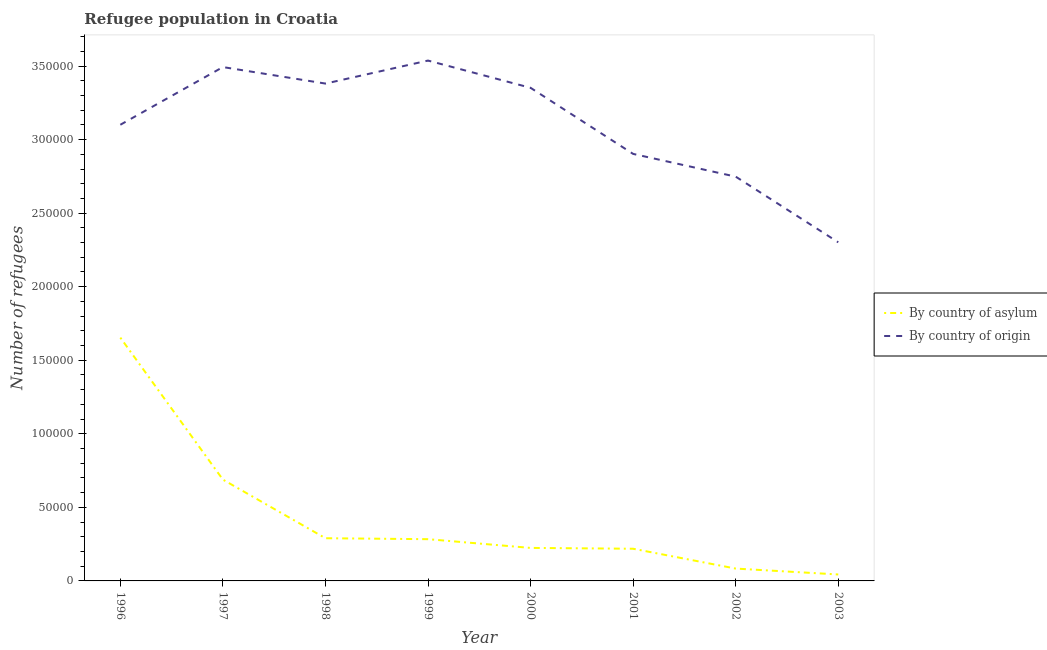


🤖 STEM SIGHT SUMMARY:
between population in Croatia'. The x-axis shows Year and the y-axis shows Population (% of total).



In [8]:
import torch
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display
import os

# 1. LOAD MODEL
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "/content/drive/MyDrive/STEM_Sight_Line_Final"

print("⏳ Loading Line Expert...")
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to(device)
model.eval()

# 2. ENHANCED TEST FUNCTION
def run_visual_test():
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Display the image
        print(f"\n📸 Input Image: {filename}")
        display.display(display.Image(filename, width=400))

        # Process Image
        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        # Generate Summary
        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=2,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # Clean Output
        sequence = processor.batch_decode(outputs)[0]
        # Removing the prompt and special tokens for a clean read
        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "="*50)
        print(f"🤖 STEM SIGHT SUMMARY:\n{clean_output}")
        print("="*50 + "\n")

# 3. START
run_visual_test()

⏳ Loading Line Expert...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Saving 16887.png to 16887.png

📸 Input Image: 16887.png


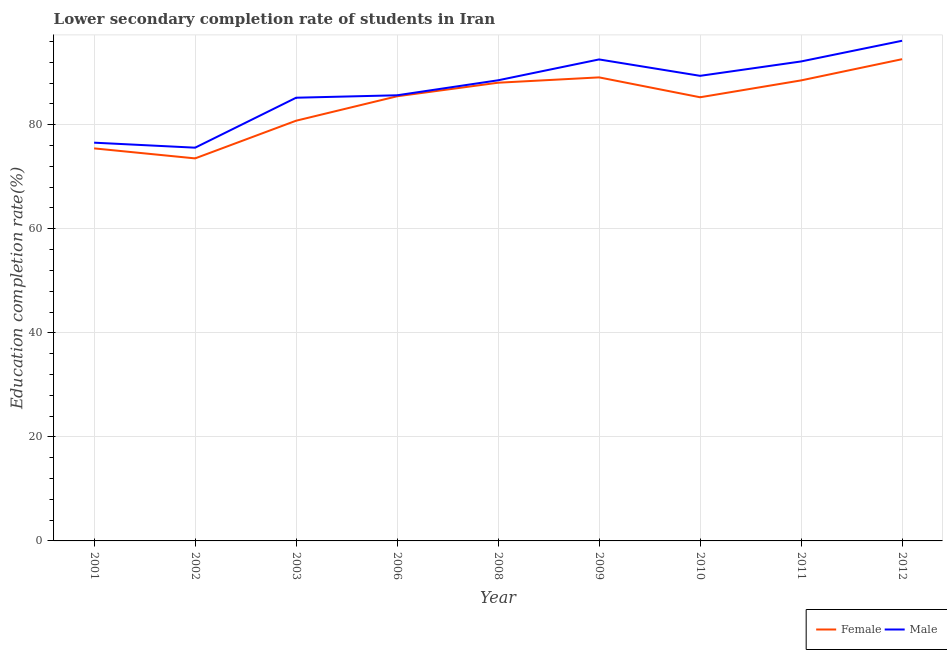


🤖 STEM SIGHT SUMMARY:
. The x-axis shows Year and the y-axis shows Number of days.



In [9]:
import torch
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display
import os

# 1. LOAD MODEL
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "/content/drive/MyDrive/STEM_Sight_Line_Final"

print("⏳ Loading Line Expert...")
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to(device)
model.eval()

# 2. ENHANCED TEST FUNCTION
def run_visual_test():
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Display the image
        print(f"\n📸 Input Image: {filename}")
        display.display(display.Image(filename, width=400))

        # Process Image
        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        # Generate Summary
        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=2,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # Clean Output
        sequence = processor.batch_decode(outputs)[0]
        # Removing the prompt and special tokens for a clean read
        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "="*50)
        print(f"🤖 STEM SIGHT SUMMARY:\n{clean_output}")
        print("="*50 + "\n")

# 3. START
run_visual_test()

⏳ Loading Line Expert...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Saving 16908.png to 16908.png

📸 Input Image: 16908.png


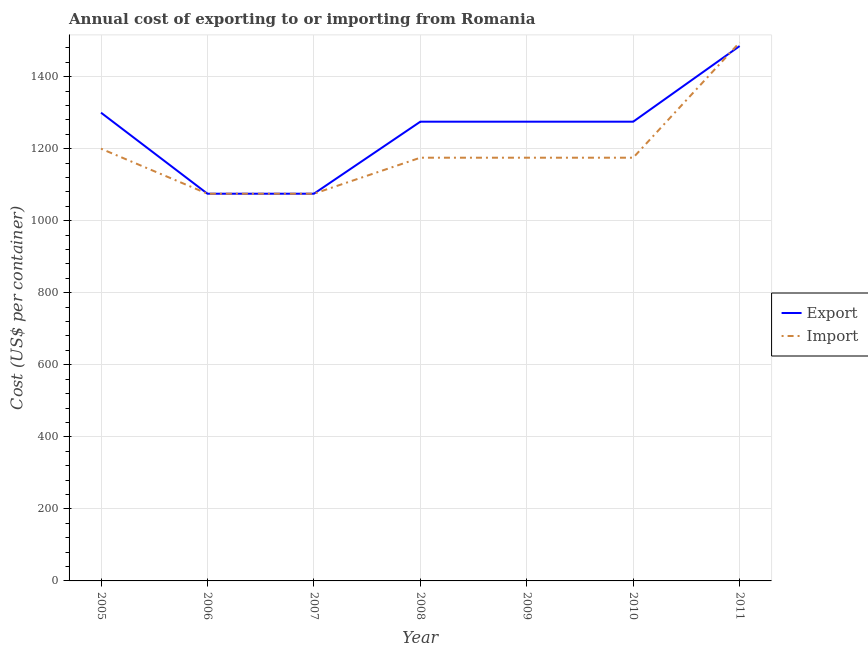


🤖 STEM SIGHT SUMMARY:
. The x-axis shows Year and the y-axis shows Average number of days.



In [10]:
import torch
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display
import os

# 1. LOAD MODEL
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "/content/drive/MyDrive/STEM_Sight_Line_Final"

print("⏳ Loading Line Expert...")
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to(device)
model.eval()

# 2. ENHANCED TEST FUNCTION
def run_visual_test():
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Display the image
        print(f"\n📸 Input Image: {filename}")
        display.display(display.Image(filename, width=400))

        # Process Image
        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        # Generate Summary
        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=2,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # Clean Output
        sequence = processor.batch_decode(outputs)[0]
        # Removing the prompt and special tokens for a clean read
        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "="*50)
        print(f"🤖 STEM SIGHT SUMMARY:\n{clean_output}")
        print("="*50 + "\n")

# 3. START
run_visual_test()

⏳ Loading Line Expert...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Saving linr_chart1.png to linr_chart1.png

📸 Input Image: linr_chart1.png


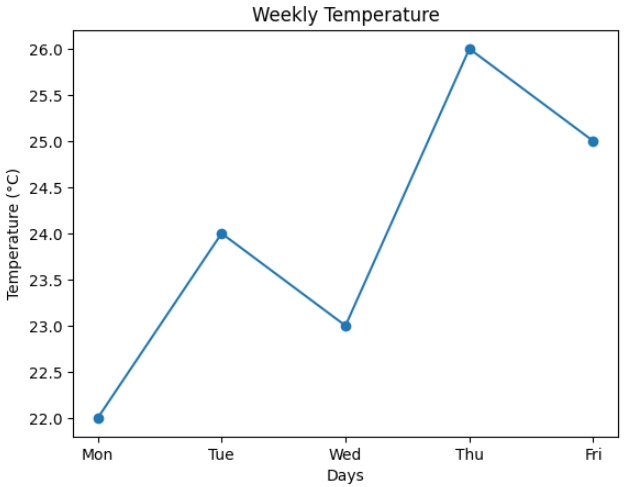


🤖 STEM SIGHT SUMMARY:
were a line titled 'Wastee emissions (in thousand metric tons of CO2 equivalent).



In [11]:
import torch
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display
import os

# 1. LOAD MODEL
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "/content/drive/MyDrive/STEM_Sight_Line_Final"

print("⏳ Loading Line Expert...")
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to(device)
model.eval()

# 2. ENHANCED TEST FUNCTION
def run_visual_test():
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Display the image
        print(f"\n📸 Input Image: {filename}")
        display.display(display.Image(filename, width=400))

        # Process Image
        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        # Generate Summary
        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=2,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # Clean Output
        sequence = processor.batch_decode(outputs)[0]
        # Removing the prompt and special tokens for a clean read
        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "="*50)
        print(f"🤖 STEM SIGHT SUMMARY:\n{clean_output}")
        print("="*50 + "\n")

# 3. START
run_visual_test()

In [12]:
# Check the first 10 ground truth entries in your sampled data
with open("/content/line_donut_master/metadata.jsonl", 'r') as f:
    for _ in range(10):
        print(f.readline())

{"file_name": "98293.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Total labor force with tertiary education as their highest grade'. The x-axis shows Years and the y-axis shows Educated labor force (% of total).\"}"}

{"file_name": "86616.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Electricity production from renewable resources'. The x-axis shows Years and the y-axis shows Amount of electricity produced(kWh).\"}"}

{"file_name": "90675.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Global C02 emissions'. The x-axis shows Years and the y-axis shows Emissions(metric tons per capita).\"}"}

{"file_name": "102996.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Plot of CO2 intensity of Ecuador'. The x-axis shows Year and the y-axis shows Intensity (kg per kg of oil equivalent energy use).\"}"}

{"file_name": "86688.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Proportion of the total female labor force of 

In [13]:
with open("/content/line_donut_master/metadata.jsonl", 'r') as f:
    samples = [f.readline() for _ in range(20)]
    for s in samples:
        print(s)

{"file_name": "98293.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Total labor force with tertiary education as their highest grade'. The x-axis shows Years and the y-axis shows Educated labor force (% of total).\"}"}

{"file_name": "86616.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Electricity production from renewable resources'. The x-axis shows Years and the y-axis shows Amount of electricity produced(kWh).\"}"}

{"file_name": "90675.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Global C02 emissions'. The x-axis shows Years and the y-axis shows Emissions(metric tons per capita).\"}"}

{"file_name": "102996.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Plot of CO2 intensity of Ecuador'. The x-axis shows Year and the y-axis shows Intensity (kg per kg of oil equivalent energy use).\"}"}

{"file_name": "86688.png", "ground_truth": "{\"gt_parse\": \"This is a line titled 'Proportion of the total female labor force of 

⏳ Loading Line Expert...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Saving 16983.png to 16983.png

📸 Input Image: 16983.png


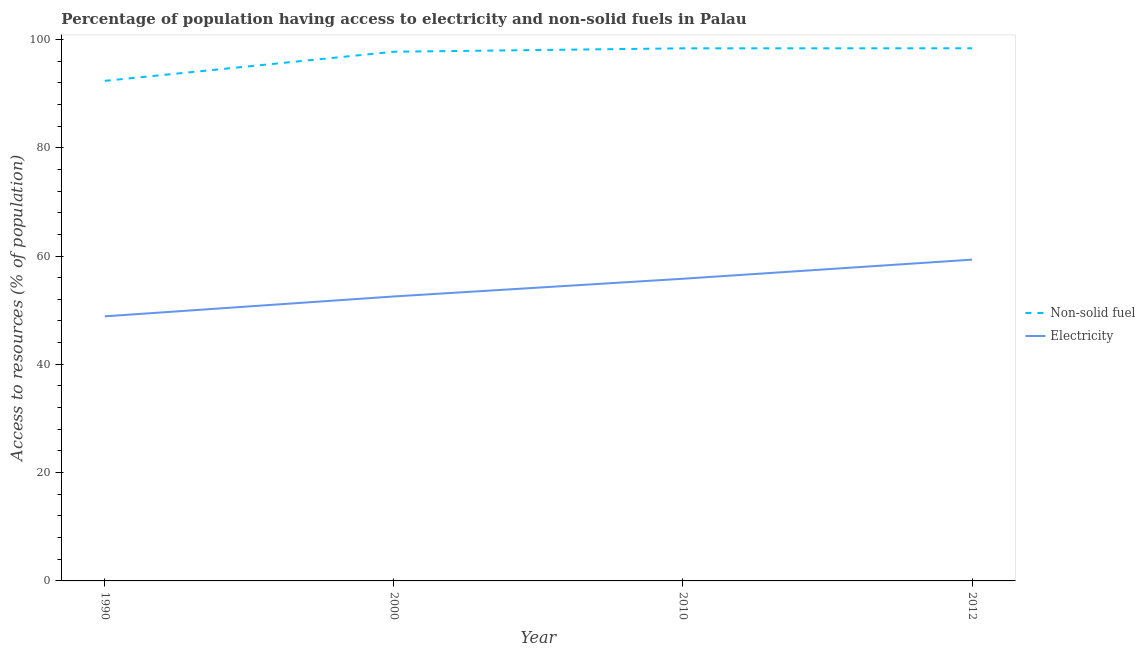


🤖 STEM SIGHT SUMMARY:
of population having access to electricity and non-solid fuels in Palau'. The x-axis shows Year and the y-axis shows Access to resources (% of population).



In [14]:
import torch
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display
import os

# 1. LOAD MODEL
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "/content/drive/MyDrive/STEM_Sight_Line_Final"

print("⏳ Loading Line Expert...")
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to(device)
model.eval()

# 2. ENHANCED TEST FUNCTION
def run_visual_test():
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Display the image
        print(f"\n📸 Input Image: {filename}")
        display.display(display.Image(filename, width=400))

        # Process Image
        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        # Generate Summary
        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=2,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # Clean Output
        sequence = processor.batch_decode(outputs)[0]
        # Removing the prompt and special tokens for a clean read
        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "="*50)
        print(f"🤖 STEM SIGHT SUMMARY:\n{clean_output}")
        print("="*50 + "\n")

# 3. START
run_visual_test()

In [16]:
import os
import torch
from torch.optim import AdamW
from datasets import load_dataset
from transformers import DonutProcessor, VisionEncoderDecoderModel, TrainingArguments, Trainer, get_cosine_schedule_with_warmup

# 1. LOAD DATASET (Keep your 10k sampled master directory)
dataset = load_dataset("imagefolder", data_dir="/content/line_donut_master")

# 2. LOAD VBAR MASTER (Start fresh from the 'Smart' weights)
model_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to("cuda")
model.config.tie_word_embeddings = False

# 3. PATHS
LINE_SAVE_PATH = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"
os.makedirs(LINE_SAVE_PATH, exist_ok=True)

# 4. STABILITY ARGUMENTS
training_args = TrainingArguments(
    output_dir=LINE_SAVE_PATH,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=1,                # Reduced to 1 to prevent template memorization
    learning_rate=5e-6,                # LOWER learning rate (Crucial!)
    weight_decay=0.05,                 # Increased weight decay to keep weights "simple"
    logging_steps=50,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    fp16=True,
    remove_unused_columns=False,
    report_to="none"
)

# 5. INITIALIZE
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=donut_collator, # Use the same collator function from your previous cell
)

print("🚀 Launching Stability Reset Training...")
trainer.train()

Resolving data files:   0%|          | 0/10001 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


🚀 Launching Stability Reset Training...


Step,Training Loss
50,0.914242
100,0.156341
150,0.145633
200,0.151423
250,0.146092
300,0.146518
350,0.141292
400,0.137587
450,0.130373
500,0.119992


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=625, training_loss=0.20320948867797853, metrics={'train_runtime': 1378.6723, 'train_samples_per_second': 7.253, 'train_steps_per_second': 0.453, 'total_flos': 5.31577112887296e+18, 'train_loss': 0.20320948867797853, 'epoch': 1.0})

In [24]:
import torch
import os
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# 1. SETUP PATHS
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
weights_path = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"

print("⏳ Force-loading STEM Sight Line Expert...")

# 2. LOAD ARCHITECTURE (The Blueprint)
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

# 3. MANUAL WEIGHT INJECTION (The Brains)
# We find the file manually to avoid path errors
possible_files = ["model.safetensors", "pytorch_model.bin"]
loaded = False

for f in possible_files:
    file_path = os.path.join(weights_path, f)
    if os.path.exists(file_path):
        print(f"🧠 Found weights: {f}. Injecting...")
        if f.endswith(".safetensors"):
            from safetensors.torch import load_file
            state_dict = load_file(file_path, device=device)
        else:
            state_dict = torch.load(file_path, map_location=device)

        # This is the "surgery" that puts the new weights into the model
        model.load_state_dict(state_dict, strict=False)
        loaded = True
        break

if not loaded:
    print("❌ ERROR: Could not find model.safetensors or pytorch_model.bin in your folder.")
else:
    model.eval()
    print("✅ SUCCESS: Expert Weights Injected into Architecture!")

# 4. INFERENCE FUNCTION
def run_stem_sight_test():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"\n📸 Testing Image: {filename}")
        display.display(display.Image(filename, width=450))

        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=1.5,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        sequence = processor.batch_decode(outputs.sequences)[0]
        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "═"*50)
        print(f"🤖 AI SUMMARY: {clean_output}")
        print("═"*50 + "\n")

# START THE TEST
if loaded:
    run_stem_sight_test()

⏳ Force-loading STEM Sight Line Expert...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


❌ ERROR: Could not find model.safetensors or pytorch_model.bin in your folder.


🧠 Loading weights from: /content/drive/MyDrive/STEM_Sight_Line_V2_Fixed/checkpoint-625/model.safetensors


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Line Expert is ready!


Saving linr_chart1.png to linr_chart1 (2).png

🔍 Analyzing: linr_chart1 (2).png


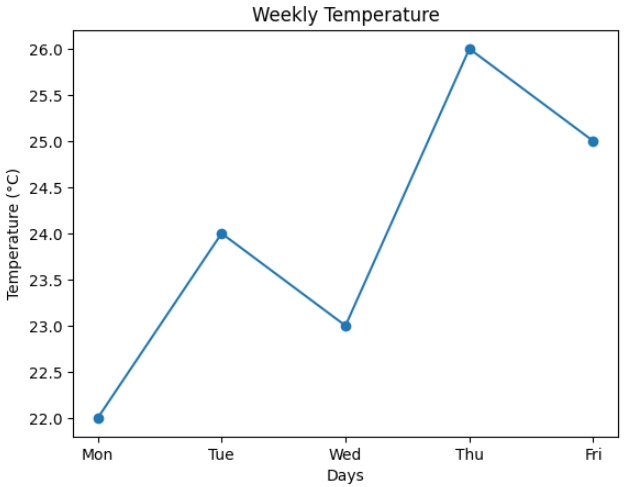


══════════════════════════════════════════════════
🤖 AI SUMMARY: 26.0'. The x-axis shows Years and the y-axis shows % of total ages 15-64.
══════════════════════════════════════════════════



In [27]:
import torch
import os
import glob
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# 1. SETUP PATHS
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
base_weights_path = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"

# 2. ACCURATE WEIGHT FINDER (Targeting pytorch_model.bin or model.safetensors)
possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_weight_files:
    possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "model.safetensors"), recursive=True)

if not possible_weight_files:
    raise FileNotFoundError("Could not find weights. Check your Drive path!")

weights_file = sorted(possible_weight_files)[-1]
print(f"🧠 Loading weights from: {weights_file}")

# 3. RECONSTRUCT MODEL
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device, weights_only=False)

model.load_state_dict(state_dict, strict=False)
model.eval()
print("✅ STEM Sight Line Expert is ready!")

# 4. FIXED INFERENCE FUNCTION
def run_final_test():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"\n🔍 Analyzing: {filename}")
        display.display(display.Image(filename, width=450))

        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=1.5,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # FIX: Handle the tensor output directly
        sequence = processor.batch_decode(outputs)[0]

        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "═"*50)
        print(f"🤖 AI SUMMARY: {clean_output}")
        print("═"*50 + "\n")

run_final_test()

🧠 Loading weights from: /content/drive/MyDrive/STEM_Sight_Line_V2_Fixed/checkpoint-625/model.safetensors


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Line Expert is ready!


Saving 16961.png to 16961.png

🔍 Analyzing: 16961.png


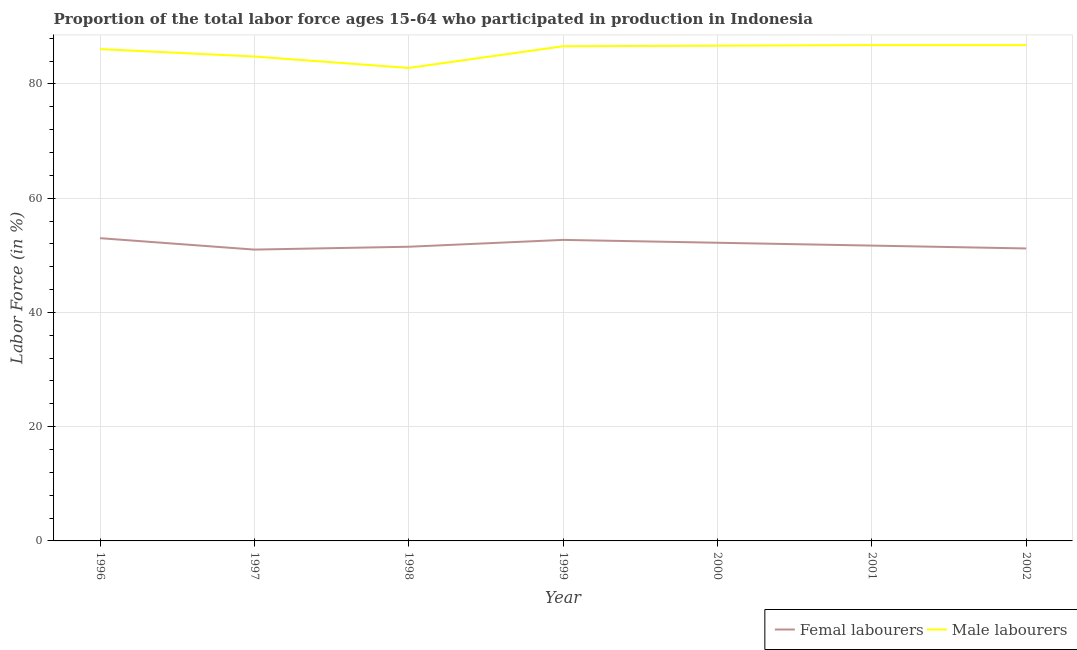


══════════════════════════════════════════════════
🤖 AI SUMMARY: Proportion of the total labor force ages 15-64 who participated in production in Indonesia'. The x-axis shows Year and the y-axis shows Labor Force (in %).
══════════════════════════════════════════════════



In [28]:
import torch
import os
import glob
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# 1. SETUP PATHS
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
base_weights_path = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"

# 2. ACCURATE WEIGHT FINDER (Targeting pytorch_model.bin or model.safetensors)
possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_weight_files:
    possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "model.safetensors"), recursive=True)

if not possible_weight_files:
    raise FileNotFoundError("Could not find weights. Check your Drive path!")

weights_file = sorted(possible_weight_files)[-1]
print(f"🧠 Loading weights from: {weights_file}")

# 3. RECONSTRUCT MODEL
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device, weights_only=False)

model.load_state_dict(state_dict, strict=False)
model.eval()
print("✅ STEM Sight Line Expert is ready!")

# 4. FIXED INFERENCE FUNCTION
def run_final_test():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"\n🔍 Analyzing: {filename}")
        display.display(display.Image(filename, width=450))

        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=1.5,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # FIX: Handle the tensor output directly
        sequence = processor.batch_decode(outputs)[0]

        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "═"*50)
        print(f"🤖 AI SUMMARY: {clean_output}")
        print("═"*50 + "\n")

run_final_test()

🧠 Loading weights from: /content/drive/MyDrive/STEM_Sight_Line_V2_Fixed/checkpoint-625/model.safetensors


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Line Expert is ready!


Saving 17106.png to 17106.png

🔍 Analyzing: 17106.png


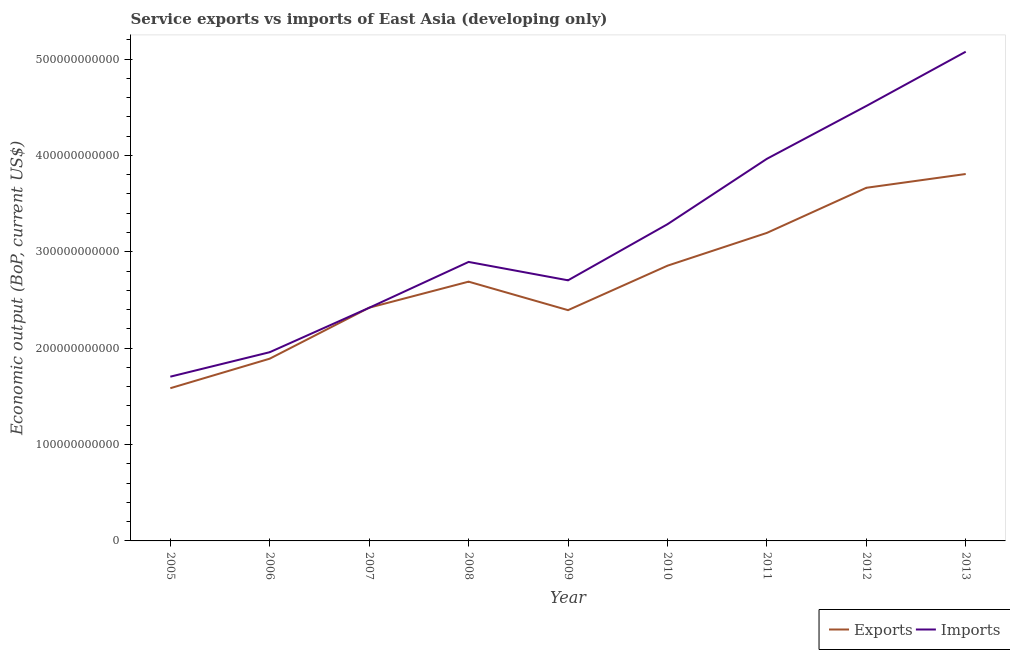


══════════════════════════════════════════════════
🤖 AI SUMMARY: Service exports vs imports of East Asia (developing only)'. The x-axis shows Year and the y-axis shows Exports(% of total merchandise exports).
══════════════════════════════════════════════════



In [29]:
import torch
import os
import glob
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# 1. SETUP PATHS
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
base_weights_path = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"

# 2. ACCURATE WEIGHT FINDER (Targeting pytorch_model.bin or model.safetensors)
possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_weight_files:
    possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "model.safetensors"), recursive=True)

if not possible_weight_files:
    raise FileNotFoundError("Could not find weights. Check your Drive path!")

weights_file = sorted(possible_weight_files)[-1]
print(f"🧠 Loading weights from: {weights_file}")

# 3. RECONSTRUCT MODEL
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device, weights_only=False)

model.load_state_dict(state_dict, strict=False)
model.eval()
print("✅ STEM Sight Line Expert is ready!")

# 4. FIXED INFERENCE FUNCTION
def run_final_test():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"\n🔍 Analyzing: {filename}")
        display.display(display.Image(filename, width=450))

        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=1.5,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # FIX: Handle the tensor output directly
        sequence = processor.batch_decode(outputs)[0]

        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "═"*50)
        print(f"🤖 AI SUMMARY: {clean_output}")
        print("═"*50 + "\n")

run_final_test()

🧠 Loading weights from: /content/drive/MyDrive/STEM_Sight_Line_V2_Fixed/checkpoint-625/model.safetensors


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Line Expert is ready!


Saving 17322.png to 17322.png

🔍 Analyzing: 17322.png


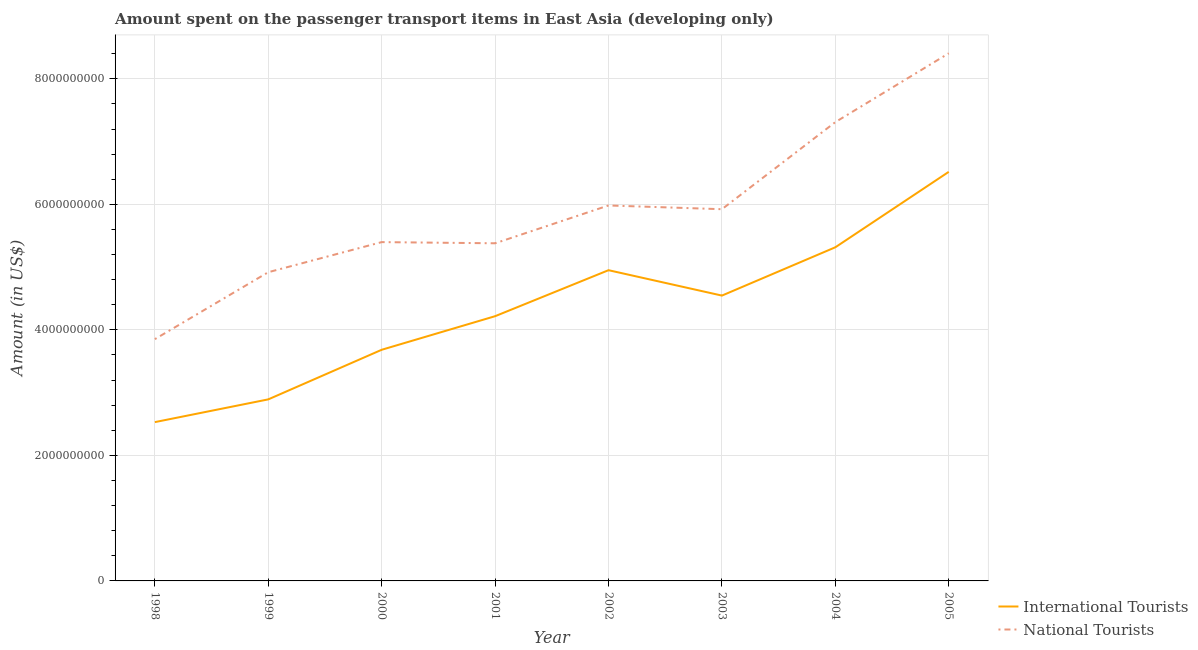


══════════════════════════════════════════════════
🤖 AI SUMMARY: <Amount spent on the passenger transport items in East Asia (developing only)'. The x-axis shows Year and the y-axis shows Amount (in US$).
══════════════════════════════════════════════════



In [30]:
import torch
import os
import glob
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# 1. SETUP PATHS
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
base_weights_path = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"

# 2. ACCURATE WEIGHT FINDER (Targeting pytorch_model.bin or model.safetensors)
possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_weight_files:
    possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "model.safetensors"), recursive=True)

if not possible_weight_files:
    raise FileNotFoundError("Could not find weights. Check your Drive path!")

weights_file = sorted(possible_weight_files)[-1]
print(f"🧠 Loading weights from: {weights_file}")

# 3. RECONSTRUCT MODEL
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device, weights_only=False)

model.load_state_dict(state_dict, strict=False)
model.eval()
print("✅ STEM Sight Line Expert is ready!")

# 4. FIXED INFERENCE FUNCTION
def run_final_test():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"\n🔍 Analyzing: {filename}")
        display.display(display.Image(filename, width=450))

        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=1.5,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # FIX: Handle the tensor output directly
        sequence = processor.batch_decode(outputs)[0]

        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "═"*50)
        print(f"🤖 AI SUMMARY: {clean_output}")
        print("═"*50 + "\n")

run_final_test()

🧠 Loading weights from: /content/drive/MyDrive/STEM_Sight_Line_V2_Fixed/checkpoint-625/model.safetensors


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Line Expert is ready!


Saving 17767.png to 17767.png

🔍 Analyzing: 17767.png


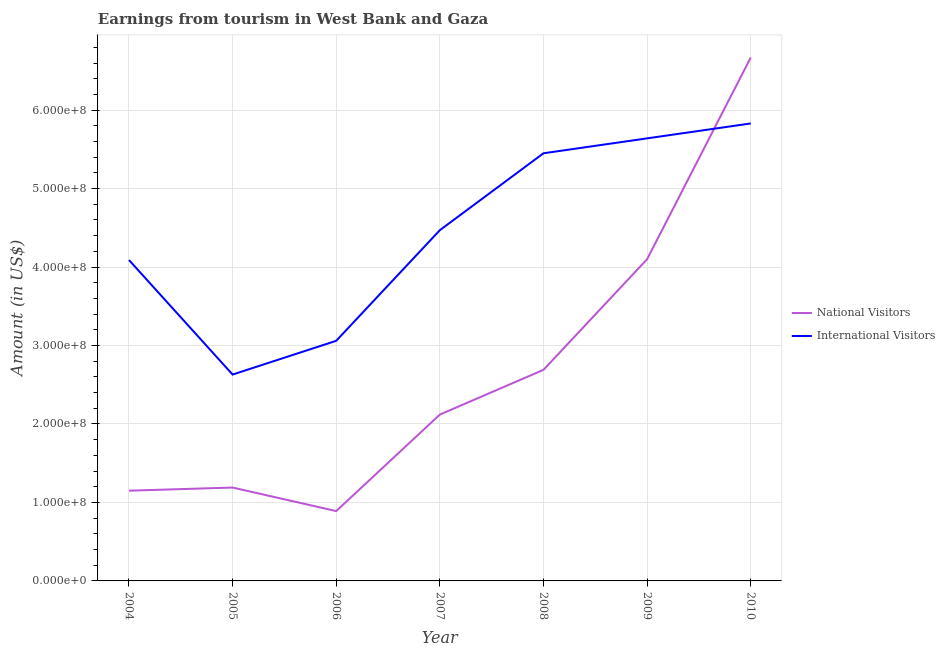


══════════════════════════════════════════════════
🤖 AI SUMMARY: Earnings from tourism in West Bank and Gaza'. The x-axis shows Year and the y-axis shows Amount (in US$).
══════════════════════════════════════════════════



In [31]:
import torch
import os
import glob
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# 1. SETUP PATHS
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
base_weights_path = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"

# 2. ACCURATE WEIGHT FINDER (Targeting pytorch_model.bin or model.safetensors)
possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_weight_files:
    possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "model.safetensors"), recursive=True)

if not possible_weight_files:
    raise FileNotFoundError("Could not find weights. Check your Drive path!")

weights_file = sorted(possible_weight_files)[-1]
print(f"🧠 Loading weights from: {weights_file}")

# 3. RECONSTRUCT MODEL
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device, weights_only=False)

model.load_state_dict(state_dict, strict=False)
model.eval()
print("✅ STEM Sight Line Expert is ready!")

# 4. FIXED INFERENCE FUNCTION
def run_final_test():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"\n🔍 Analyzing: {filename}")
        display.display(display.Image(filename, width=450))

        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=1.5,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # FIX: Handle the tensor output directly
        sequence = processor.batch_decode(outputs)[0]

        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "═"*50)
        print(f"🤖 AI SUMMARY: {clean_output}")
        print("═"*50 + "\n")

run_final_test()

🧠 Loading weights from: /content/drive/MyDrive/STEM_Sight_Line_V2_Fixed/checkpoint-625/model.safetensors


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Line Expert is ready!


Saving line-chart2.png to line-chart2.png

🔍 Analyzing: line-chart2.png


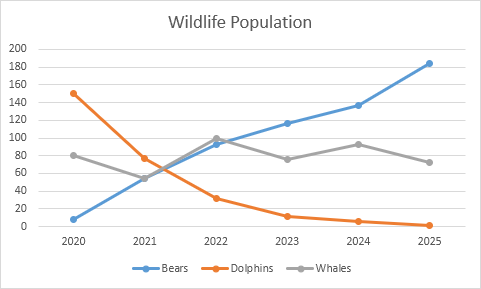


══════════════════════════════════════════════════
🤖 AI SUMMARY: Feefficial relief reopulation'. The x-axis shows Years and the y-axis shows Population(% of total).
══════════════════════════════════════════════════



In [32]:
import torch
import os
import glob
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# 1. SETUP PATHS
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
base_weights_path = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"

# 2. ACCURATE WEIGHT FINDER (Targeting pytorch_model.bin or model.safetensors)
possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_weight_files:
    possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "model.safetensors"), recursive=True)

if not possible_weight_files:
    raise FileNotFoundError("Could not find weights. Check your Drive path!")

weights_file = sorted(possible_weight_files)[-1]
print(f"🧠 Loading weights from: {weights_file}")

# 3. RECONSTRUCT MODEL
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device, weights_only=False)

model.load_state_dict(state_dict, strict=False)
model.eval()
print("✅ STEM Sight Line Expert is ready!")

# 4. FIXED INFERENCE FUNCTION
def run_final_test():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"\n🔍 Analyzing: {filename}")
        display.display(display.Image(filename, width=450))

        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=1.5,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # FIX: Handle the tensor output directly
        sequence = processor.batch_decode(outputs)[0]

        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "═"*50)
        print(f"🤖 AI SUMMARY: {clean_output}")
        print("═"*50 + "\n")

run_final_test()

🧠 Loading weights from: /content/drive/MyDrive/STEM_Sight_Line_V2_Fixed/checkpoint-625/model.safetensors


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Line Expert is ready!


Saving Line-Graph3.png to Line-Graph3.png

🔍 Analyzing: Line-Graph3.png


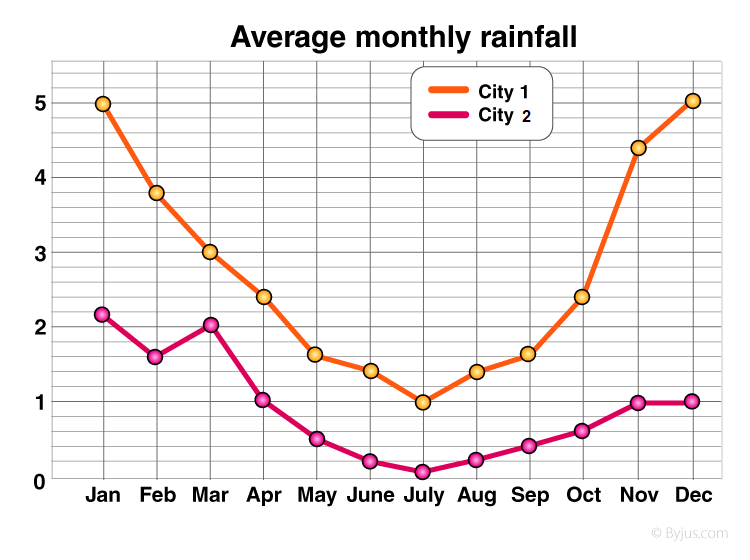


══════════════════════════════════════════════════
🤖 AI SUMMARY: average monthly rainfall'. The x-axis shows Years and the y-axis shows Average monthly (in %).
══════════════════════════════════════════════════



In [33]:
import torch
import os
import glob
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# 1. SETUP PATHS
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
base_weights_path = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"

# 2. ACCURATE WEIGHT FINDER (Targeting pytorch_model.bin or model.safetensors)
possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_weight_files:
    possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "model.safetensors"), recursive=True)

if not possible_weight_files:
    raise FileNotFoundError("Could not find weights. Check your Drive path!")

weights_file = sorted(possible_weight_files)[-1]
print(f"🧠 Loading weights from: {weights_file}")

# 3. RECONSTRUCT MODEL
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device, weights_only=False)

model.load_state_dict(state_dict, strict=False)
model.eval()
print("✅ STEM Sight Line Expert is ready!")

# 4. FIXED INFERENCE FUNCTION
def run_final_test():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"\n🔍 Analyzing: {filename}")
        display.display(display.Image(filename, width=450))

        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=1.5,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # FIX: Handle the tensor output directly
        sequence = processor.batch_decode(outputs)[0]

        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "═"*50)
        print(f"🤖 AI SUMMARY: {clean_output}")
        print("═"*50 + "\n")

run_final_test()

🧠 Loading weights from: /content/drive/MyDrive/STEM_Sight_Line_V2_Fixed/checkpoint-625/model.safetensors


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Line Expert is ready!


Saving 17256.png to 17256.png

🔍 Analyzing: 17256.png


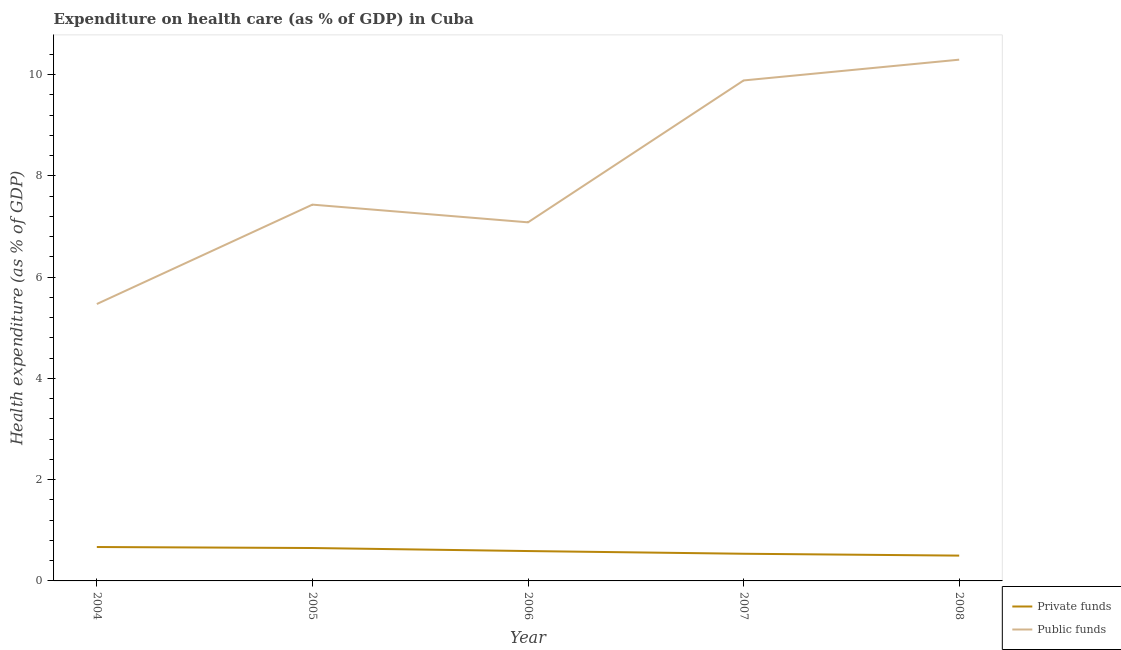


══════════════════════════════════════════════════
🤖 AI SUMMARY: Employment on health care (as % of GDP) in Cuba'. The x-axis shows Year and the y-axis shows Health expenditure (as % of GDP).
══════════════════════════════════════════════════



In [34]:
import torch
import os
import glob
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# 1. SETUP PATHS
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
base_weights_path = "/content/drive/MyDrive/STEM_Sight_Line_V2_Fixed"

# 2. ACCURATE WEIGHT FINDER (Targeting pytorch_model.bin or model.safetensors)
possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_weight_files:
    possible_weight_files = glob.glob(os.path.join(base_weights_path, "**", "model.safetensors"), recursive=True)

if not possible_weight_files:
    raise FileNotFoundError("Could not find weights. Check your Drive path!")

weights_file = sorted(possible_weight_files)[-1]
print(f"🧠 Loading weights from: {weights_file}")

# 3. RECONSTRUCT MODEL
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device, weights_only=False)

model.load_state_dict(state_dict, strict=False)
model.eval()
print("✅ STEM Sight Line Expert is ready!")

# 4. FIXED INFERENCE FUNCTION
def run_final_test():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f"\n🔍 Analyzing: {filename}")
        display.display(display.Image(filename, width=450))

        image = Image.open(filename).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=1.5,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        # FIX: Handle the tensor output directly
        sequence = processor.batch_decode(outputs)[0]

        clean_output = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()

        print("\n" + "═"*50)
        print(f"🤖 AI SUMMARY: {clean_output}")
        print("═"*50 + "\n")

run_final_test()